# **Task 1: Problem Identification**

Problem type: **Image classification**

Reason:
Each image is assigned exactly one label (normal, scratch, dent, stain).
There are no bounding boxes (object detection), no pixel‑level masks (semantic or instance segmentation).
The task is to classify an entire image into one of several categories.

# **Task 2: Dataset Exploration**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once your Drive is mounted, you can explore its contents. You'll typically find your files under `/content/drive/MyDrive/`. Please specify the path to your dataset within Google Drive, and I can help you load it.

In [ ]:
# 1. Number of Classes and Number of images per Class

! pip3 install opencv-python
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

dataset_path = "/content/drive/MyDrive/Bitsom Assignments Files/images"

classes = ["normal", "scratch", "dent", "stain"]
print(f"\nNumber of classes: {len(classes)}")

image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(class_path))
    image_count[cls] = count

# Display counts

print("\nImage Counts:")
for cls, count in image_count.items():
    print(f"{cls}: {count} images")



Number of classes: 4

Image Counts:
normal: 120 images
scratch: 120 images
dent: 120 images
stain: 120 images


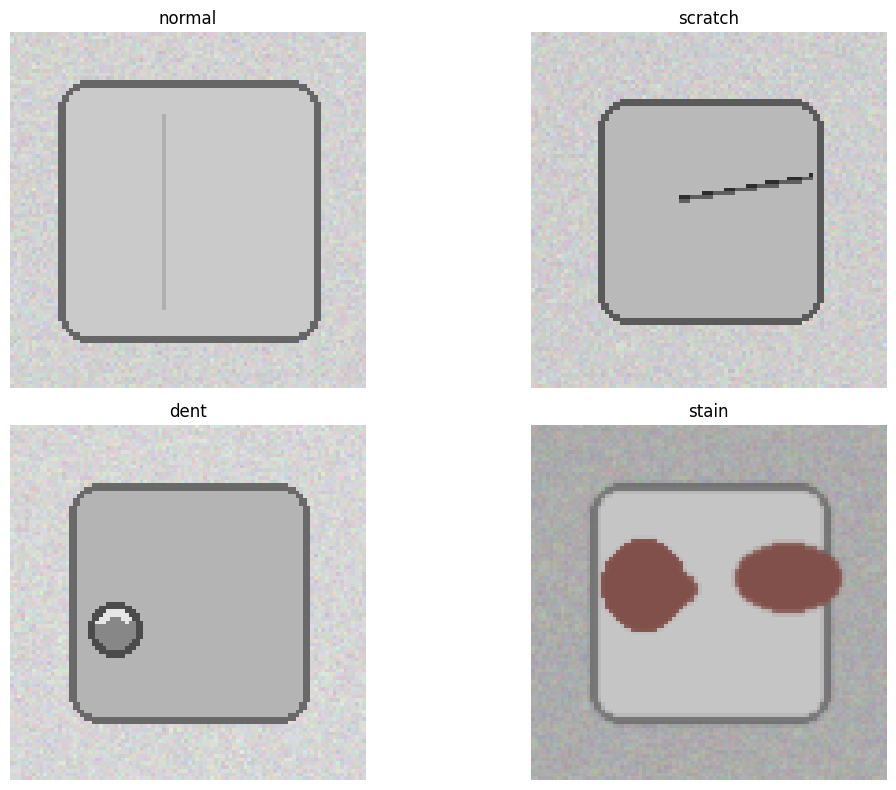

In [ ]:
# Display sample images from each class

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check image dimensions
dimensions = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        height, width, channels = img.shape
        dimensions.append((height, width, channels))

# Unique dimensions
unique_dimensions = set(dimensions)

print("Unique image dimensions:")
print(unique_dimensions)

Unique image dimensions:
{(96, 96, 3)}


In [ ]:
# Check dataset balance

import pandas as pd

df = pd.DataFrame(list(image_count.items()), columns=["class", "count"])
print("\nDataset balance:")
print(df)


Dataset balance:
     class  count
0   normal    120
1  scratch    120
2     dent    120
3    stain    120



**Final Observation:** The dataset is suitable for a CNN-based image classification task because:

*   Images are systematically organized into well-defined categories.
*   Defect patterns can be clearly identified and visually differentiated.
* Labels are pre-structured using either class-specific folders or CSV annotation files
*   Each of the four classes contains 120 images, ensuring that the dataset is balanced with no class imbalance. This will help CNN learn all classes equally.

# **Task 3: Image Preprocessing**

In [ ]:
from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array,
    ImageDataGenerator
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

dataset_path = "/content/drive/MyDrive/Bitsom Assignments Files/images"

classes = ["normal", "scratch", "dent", "stain"]

IMAGE_SIZE = (96, 96)

data = []
labels = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        # Load image and resize
        img = load_img(
            img_path,
            target_size=IMAGE_SIZE
        )

        # Convert image to array
        img_array = img_to_array(img)

        data.append(img_array)
        labels.append(cls)

# Convert to NumPy arrays
X = np.array(data, dtype="float32")
y = np.array(labels)

print("Dataset shape:", X.shape)

# Normalizing pixel values to [0, 1]
X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Dataset shape: (480, 96, 96, 3)
Minimum pixel value: 0.1764706
Maximum pixel value: 1.0


In [ ]:
# Encoding labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# One-hot encoding
y_categorical = to_categorical(y_encoded)

print("Classes:", encoder.classes_)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Classes: ['dent' 'normal' 'scratch' 'stain']
Training set shape: (384, 96, 96, 3)
Testing set shape: (96, 96, 96, 3)


In [ ]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Only rescaling for test data
test_datagen = ImageDataGenerator()

# Generate augmented batches
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=32
)

# **Task 4: CNN Model Creation**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Building CNN model
model = Sequential()

# First Convolution Block

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',     # Adding ReLU activation for non-linearity. This helps the CNN learn complex image features.
        input_shape=(96,96,3)
    )
)

# Adding Pooling layer after the first convolutional layer
model.add(
    MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Third Convolution Block
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)
model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(Dropout(0.5))

# Output Layer
model.add(
    Dense(
        4,
        activation='softmax'
    )
)

# Display Model Architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

# **Task 5: Model Training and Evaluation**

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 611ms/step - accuracy: 0.9792 - loss: 0.1094 - val_accuracy: 0.9688 - val_loss: 0.1436
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 657ms/step - accuracy: 0.9844 - loss: 0.0555 - val_accuracy: 0.9896 - val_loss: 0.0764
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 595ms/step - accuracy: 0.9896 - loss: 0.0447 - val_accuracy: 0.9896 - val_loss: 0.0840
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 635ms/step - accuracy: 0.9922 - loss: 0.0395 - val_accuracy: 0.9792 - val_loss: 0.1108
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 758ms/step - accuracy: 0.9792 - loss: 0.0443 - val_accuracy: 0.9792 - val_loss: 0.0789
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 524ms/step - accuracy: 0.9896 - loss: 0.0381 - val_accuracy: 0.9792 - val_loss: 0.0960
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 662ms/step - accuracy: 0.9896 - loss: 0.0450 - val_accuracy: 0.9792 - val_loss: 0.0964
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 517ms/step - accuracy: 0.9948 - loss: 0.0372 - val_accuracy: 

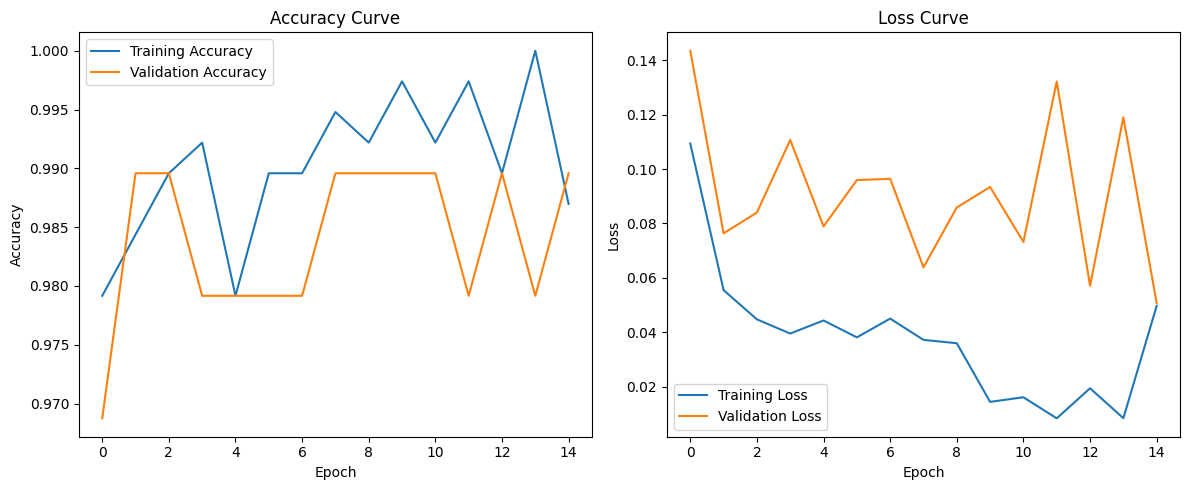

<Figure size 640x480 with 0 Axes>

In [ ]:
# Train CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

# Plot training and validation accuracy and loss curves

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss Curve
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.show()
plt.savefig('accuracy_loss_curves.png')

In [ ]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9896 - loss: 0.0507
Test Loss: 0.05073836073279381
Test Accuracy: 0.9895833134651184


In [ ]:
# Generate predictions and print classification report

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=encoder.classes_
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
              precision    recall  f1-score   support

        dent       1.00      0.96      0.98        24
      normal       1.00      1.00      1.00        24
     scratch       0.96      1.00      0.98        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.99        96
   macro avg       0.99      0.99      0.99        96
weighted avg       0.99      0.99      0.99        96



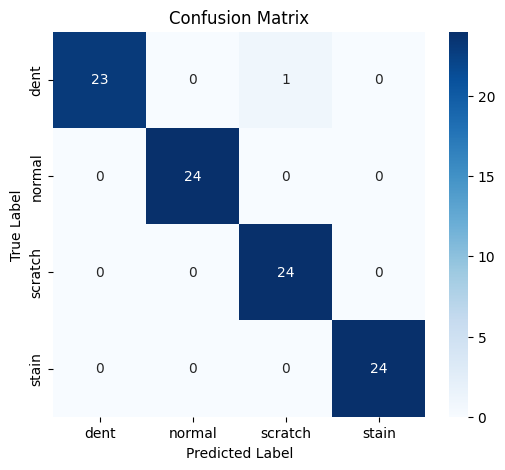

<Figure size 640x480 with 0 Axes>

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
plt.savefig('confusion_matrix.png')

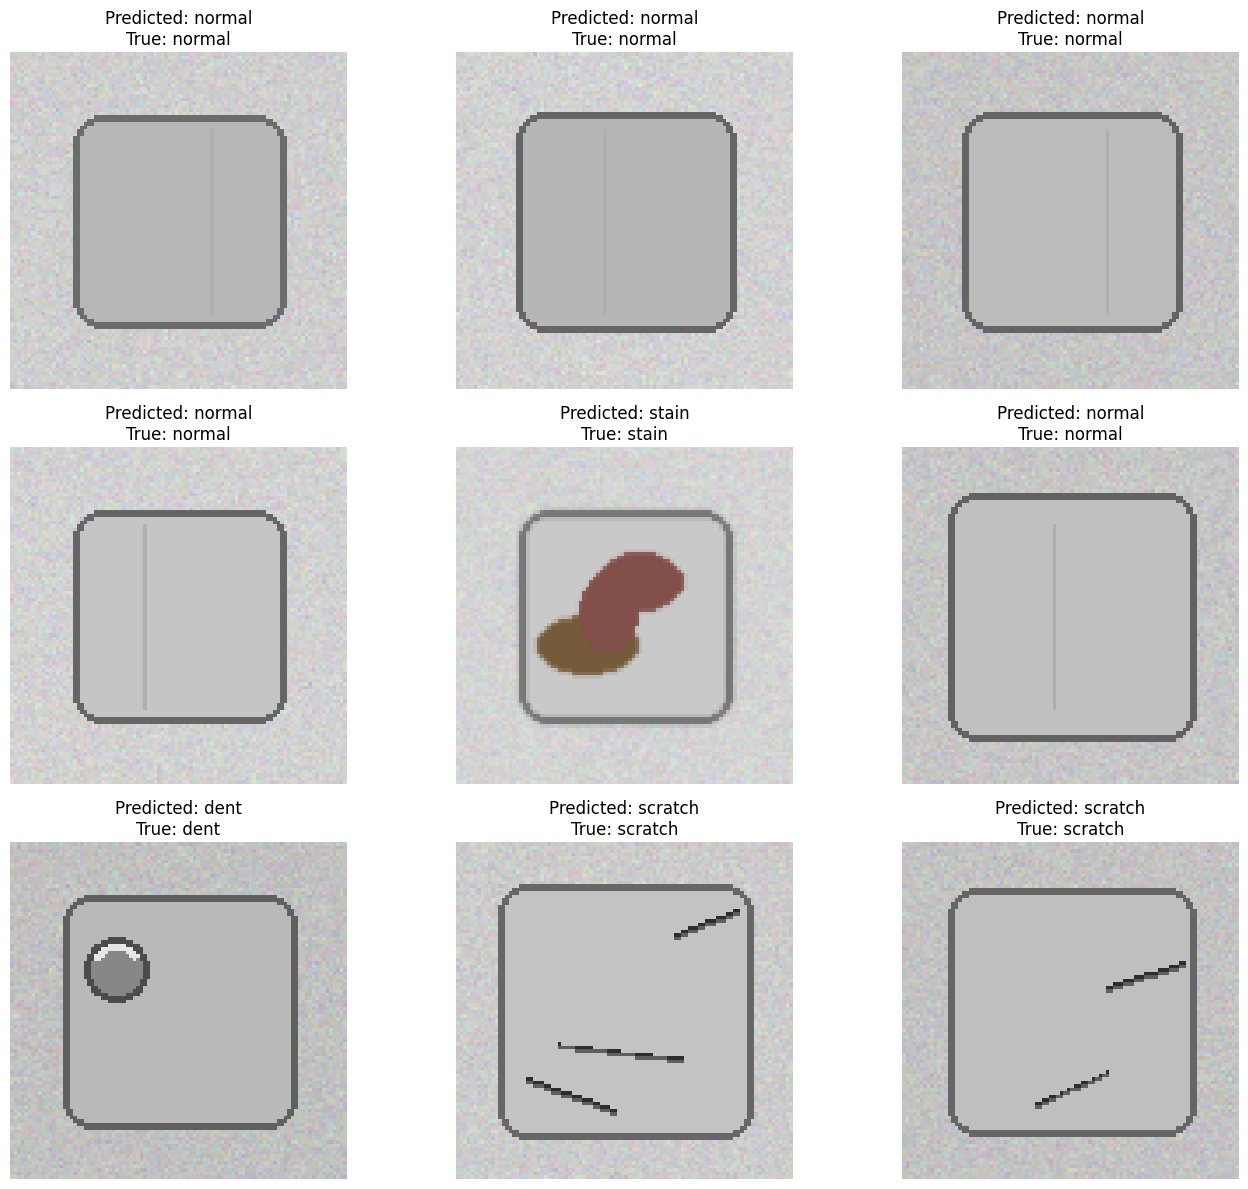

<Figure size 640x480 with 0 Axes>

In [ ]:
# Display sample predictions

plt.figure(figsize=(14,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])

    predicted_label = encoder.inverse_transform(
        [predicted_classes[i]]
    )[0]

    true_label = encoder.inverse_transform(
        [true_classes[i]]
    )[0]

    plt.title(
        f"Predicted: {predicted_label}\nTrue: {true_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()
plt.savefig('predictions_outputs.png')